In [1]:
# --- Standard library imports ---
import os                     # Operating system utilities (paths, mkdir, environment)
import sys                    # System-specific parameters and functions
import re                     # Regular expressions (parsing native_id, filenames)
import glob                   # Unix-style pathname pattern expansion (file discovery)
import warnings               # Emit and control warning messages
from collections import defaultdict  # Dict subclass with default factory
from io import BytesIO        # In-memory binary streams (images, downloads)

# --- Scientific computing and data handling ---
import numpy as np            # Numerical arrays and operations
import xarray as xr           # Labeled multi-dimensional arrays (netCDF, etc.)
import pandas as pd           # Tabular data handling (CSV/Excel)

# --- Parallel / distributed computing ---
from dask.distributed import Client  # Dask client for parallel processing
import logging               # Logging for tracking events and errors

# --- Plotting and visualization ---
import matplotlib.pyplot as plt          # Main plotting library
import matplotlib.colors as mcolors      # Color utilities and colormap helpers
import matplotlib.dates as mdates        # Date formatting for plots
from matplotlib.colors import LogNorm, LinearSegmentedColormap, ListedColormap # Color normalization and custom colormaps
import imageio                           # Read/write animated images (GIFs)
from IPython.display import Image as gifImage # Display GIFs in Jupyter notebooks

# --- Image processing ---
from PIL import Image, ImageEnhance   # Pillow for image enhancement used in RGB rendering

# --- Oceanographic / color maps ---
import cmocean                         # Oceanographic colormaps (thermal, haline, balance, etc.)
import colormaps as cmaps              # Additional colormap utilities

# --- Geospatial plotting ---
import cartopy.crs as ccrs             # Cartopy coordinate reference system

# --- Web and cloud access ---
import earthaccess                     # NASA Earthdata cloud and data access client


/accounts/gtrolley/miniforge3/envs/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# file download address https://oceandata.sci.gsfc.nasa.gov/getfile/hycom_ESPC-D-V02.mlt.20251212.nc

In [24]:
import requests
from pathlib import Path

def download_file(url, local_filename=None):
    """Download a file from a URL"""
    if local_filename is None:
        # Extract filename from URL
        local_filename = url.split('/')[-1]
    
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Raises an HTTPError for bad responses
        
        with open(local_filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        print(f"Downloaded: {local_filename}")
        return local_filename
        
    except requests.exceptions.RequestException as e:
        print(f"Error downloading file: {e}")
        return None

# Usage
url = "https://oceandata.sci.gsfc.nasa.gov/getfile/hycom_ESPC-D-V02.mlt.20251212.nc"
download_file(url)

Downloaded: hycom_ESPC-D-V02.mlt.20251212.nc


'hycom_ESPC-D-V02.mlt.20251212.nc'

In [ ]:
# function to download hycom MLD data for a date range:
# inputs: start date, end date, path to save files to
# start date and end date must be in yyyymmdd format
#GT 12/15

def download_MLT_hycom_files(start, end, savepath):
    # function to download hycom MLT data from https://oceandata.sci.gsfc.nasa.gov/
    # 2 day data upload delay
    # start date and end date must be in yyyymmdd format

    Path(savepath).mkdir(parents=True, exist_ok=True)# make folder to save files
    start = str(int(start))# deal with data types
    end = str(int(end))
    dates = pd.date_range(start=start, end=end, freq='D')
    date_list = [date.strftime('%Y%m%d') for date in dates]# list of all dates to download in yyyymmdd string format

    for date in date_list:
        filename = "hycom_ESPC-D-V02.mlt."+date+".nc"
        url = "https://oceandata.sci.gsfc.nasa.gov/getfile/"+filename
        
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()  # Raises an HTTPError for bad responses
            
            with open(savepath+filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            
            print(f"Downloaded: {filename}")
            
        except requests.exceptions.RequestException as e:
            print(f"Error downloading file: {e}")
            return None


In [20]:
download_MLT_hycom_files('20251209', '20251212', 'hycom/mlt/')

Downloaded: hycom_ESPC-D-V02.mlt.20251209.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251210.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251211.nc
Downloaded: hycom_ESPC-D-V02.mlt.20251212.nc


In [21]:
import xarray as xr
data = xr.open_dataset('hycom/mlt/hycom_ESPC-D-V02.mlt.20251209.nc')

In [22]:
data

<xarray.Dataset> Size: 77MB
Dimensions:                (time: 1, lat: 4251, lon: 4500)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2025-12-09T12:00:00
  * lat                    (lat) float64 34kB -80.0 -79.96 -79.92 ... 89.96 90.0
  * lon                    (lon) float64 36kB 0.0 0.07996 0.16 ... 359.8 359.9
Data variables:
    mixed_layer_thickness  (time, lat, lon) float32 77MB ...
Attributes:
    title:            Mixed Layer Thickness from separate HYCOM Temperature a...
    source_files:     Temperature: hycom_ESPC-D-V02.water_temp.20251209.nc, S...
    date_created:     2025-12-11
    method:           Density threshold (0.03 kg/m³) with 2m interpolation
    max_depth_limit:  1000m

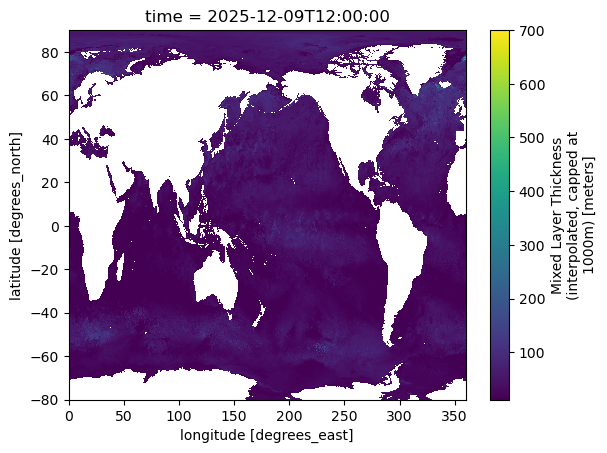

In [23]:
data.mixed_layer_thickness.plot()

In [10]:
dates = pd.date_range(start='20251120', end='20251212', freq='D')

# Convert to list of strings in your format
date_list = [date.strftime('%Y%m%d') for date in dates]
date_list

['20251120',
 '20251121',
 '20251122',
 '20251123',
 '20251124',
 '20251125',
 '20251126',
 '20251127',
 '20251128',
 '20251129',
 '20251130',
 '20251201',
 '20251202',
 '20251203',
 '20251204',
 '20251205',
 '20251206',
 '20251207',
 '20251208',
 '20251209',
 '20251210',
 '20251211',
 '20251212']